Data Normalization Check: Range [-4.91, 2.88]

Sample of Correlation Features (R-squared, Variance):
[[0.95885007 0.87458462]
 [0.8576245  0.91028752]
 [0.93043327 0.88133299]
 [0.96539215 0.87557081]
 [0.92020437 0.81626139]]
Hierarchical Clustering optimized with silhouette score, best K: 3


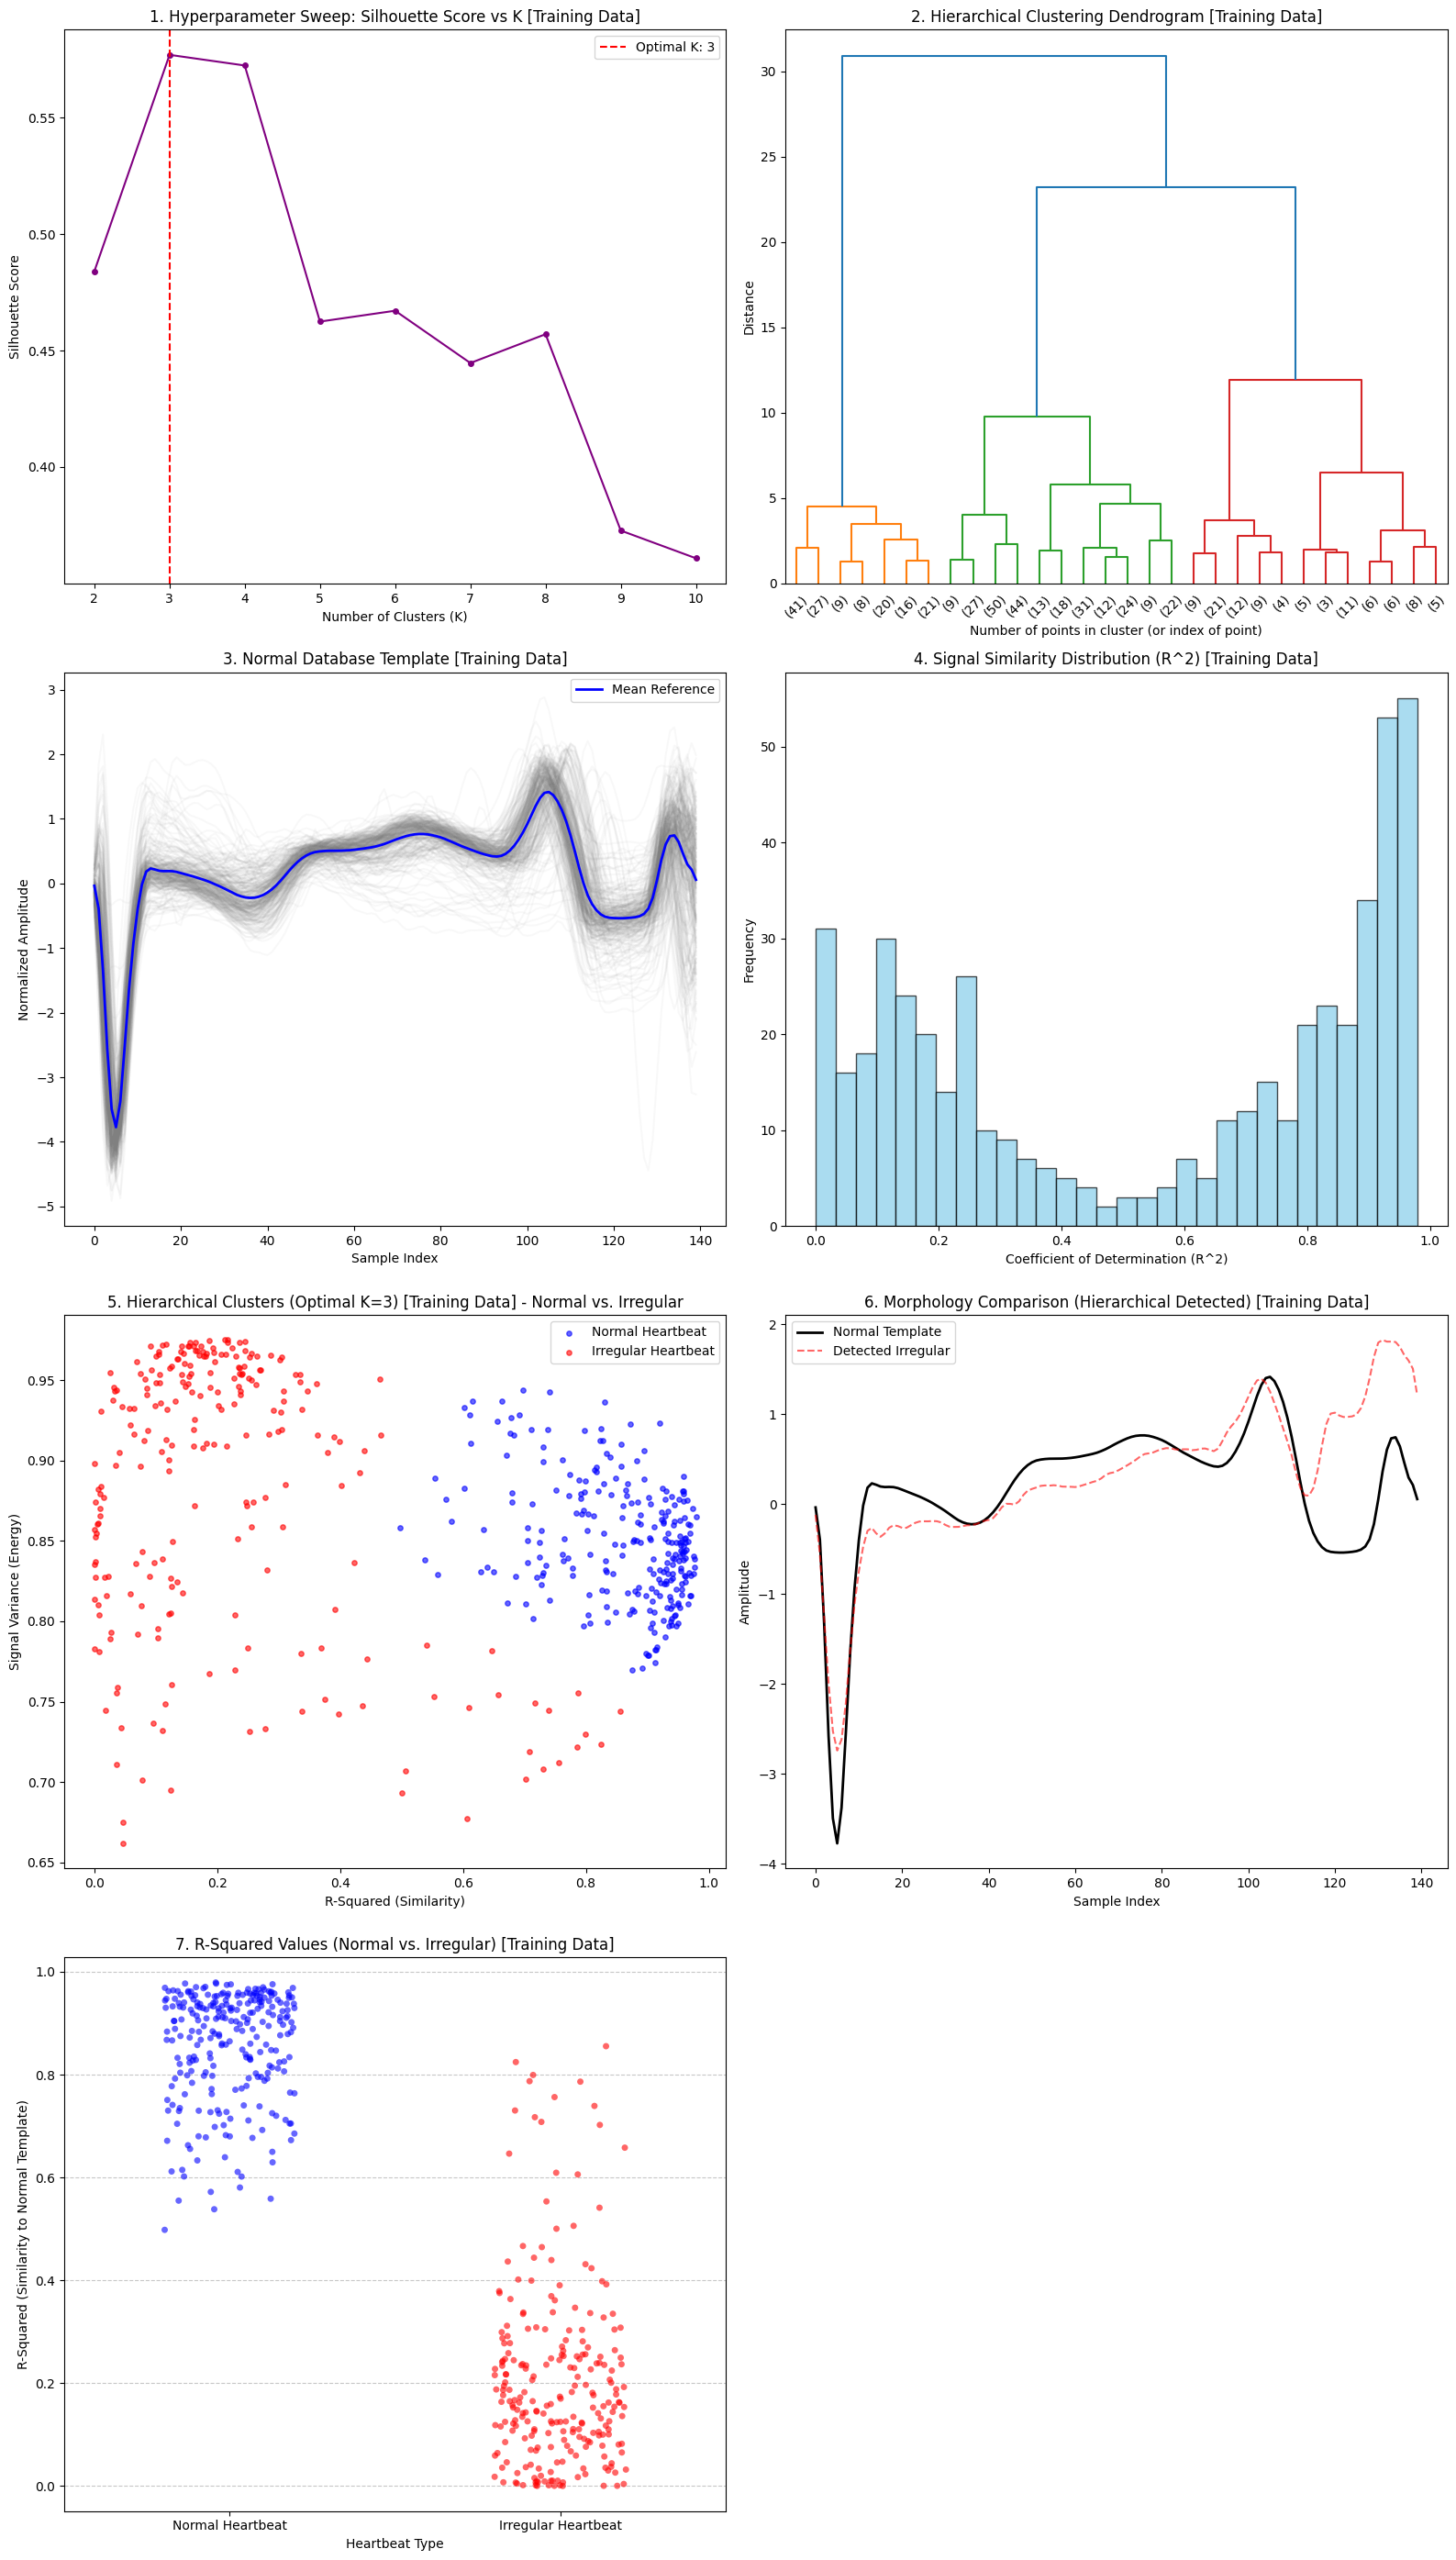

--- Hierarchical Clustering Evaluation ---
Ground Truth (Normal=1, Irregular=0) count: 292 Normal, 208 Irregular
Hierarchical Predicted (Normal=1, Irregular=0) count: 259 Normal, 241 Irregular
Accuracy: 0.9300
Precision (Normal): 0.9961
Recall (Normal): 0.8836
F1-Score (Normal): 0.9365

Confusion Matrix (True vs Predicted):
  [[TN FP]
   [FN TP]] for (Irregular vs Normal)

[[207   1]
 [ 34 258]]


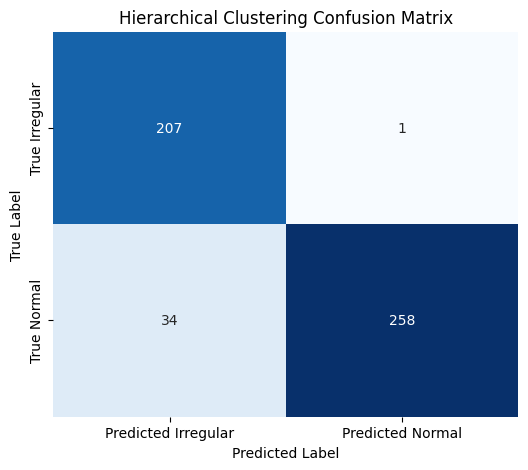

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import pandas as pd
from scipy.io import arff
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import seaborn as sns


# 1. DATA LOADING AND PREPARATION
train_data, _ = arff.loadarff("/content/drive/MyDrive/Colab Notebooks/ECG5000/ECG5000_TRAIN.arff")
train_df = pd.DataFrame(train_data)

# Convert byte strings to strings and numeric
# The last column is usually the target/label
for col in train_df.columns:
  if train_df[col].dtype == object:
    train_df[col] = train_df[col].str.decode('utf-8')

# Feature & Target Extraction (140 samples)
X_raw = train_df.iloc[:, :-1].values.astype(float) # Signal amplitude data
y = train_df.iloc[:, -1].values # Ground truth Labels

# 2. SIGNAL CONDITIONING
def bandpass_filter(data, lowcut=0.5, highcut=40.0, fs=250, order=2):
  nyq = 0.5 * fs
  low = lowcut / nyq
  high = highcut / nyq
  b, a = signal.butter(order, [low, high], btype='band')
  return signal.lfilter(b, a, data)

# Apply filtering to all signals
X_filt = np.array([bandpass_filter(row) for row in X_raw])

# 3. NORMAL DATABASE ANALYSIS & REFERENCE MEAN

# Identify normal heartbeats (Label '1' in ECG5000)
normal_mask = (y == '1')
X_normal = X_filt[normal_mask]

# Get the Mean of the Normal Heartbeats (The System Template)
mean_normal = np.mean(X_normal, axis=0)

# Check Normalization: Check if mean is near 0 and scale is consistent
data_min, data_max = X_normal.min(), X_normal.max()
print(f"Data Normalization Check: Range [{data_min:.2f}, {data_max:.2f}]")

# 4. PEARSON CORRELATION AND R-SQUARED
def get_correlation_features(X_data, reference_signal):
  features = []
  for sig in X_data:
    r, _ = pearsonr(sig, reference_signal)
    r_sq = r**2 # R-squared as a measure of similarity
    features.append([r_sq, np.var(sig)])
  return np.array(features)

X_corr_features = get_correlation_features(X_filt, mean_normal)

# Display a sample of the correlation features
print("\nSample of Correlation Features (R-squared, Variance):")
print(X_corr_features[:5])

# 5. HIERARCHICAL AGGLOMERATIVE CLUSTERING WITH SILHOUETTE SCORE OPTIMIZATION
def ecg_hierarchical_clustering_optimized(X_features, n_clusters_range=(2, 10)):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_features)

    # Compute the linkage matrix once for dendrogram and fcluster
    Z = linkage(X_scaled, 'ward')

    silhouette_scores = []
    valid_k = []
    best_score = -2.0 # Initialize with a value lower than possible silhouette scores (-1 to 1)
    best_k = n_clusters_range[0] # Default best_k in case no better score is found
    best_labels_found = None

    for k in range(n_clusters_range[0], n_clusters_range[1] + 1):
        if k < 2:
            continue

        # Use fcluster to get labels for current k
        labels = fcluster(Z, k, criterion='maxclust')

        try:
            score = silhouette_score(X_scaled, labels)
            silhouette_scores.append(score)
            valid_k.append(k)
            if score > best_score:
                best_score = score
                best_k = k
                best_labels_found = labels
        except ValueError as e:
            print(f"Could not calculate silhouette score for k={k}: {e}")

    if best_labels_found is None and len(valid_k) > 0:
        print("Optimization failed to find valid silhouette scores. Using default k=2.")
        best_k = valid_k[0]
        best_labels_found = fcluster(Z, best_k, criterion='maxclust')
    elif best_labels_found is None and len(valid_k) == 0:
         # Fallback if no valid k was found at all
        best_k = n_clusters_range[0] if n_clusters_range[0] >= 2 else 2
        best_labels_found = fcluster(Z, best_k, criterion='maxclust')


    return best_labels_found, Z, scaler, best_k, silhouette_scores, valid_k

# Call Hierarchical Clustering (with optimization for n_clusters)
final_labels_hierarchical, linkage_matrix_train, scaler_hierarchical_train, best_k_hc_train, silhouette_scores_hc, valid_k_range_hc = ecg_hierarchical_clustering_optimized(X_corr_features)

print(f"Hierarchical Clustering optimized with silhouette score, best K: {best_k_hc_train}")

def plot_hierarchical_report(X_raw, X_filt, X_normal, mean_normal, labels, X_features, linkage_matrix, valid_hp_values=None, scores=None, best_hp=None, title_suffix=""):
    fig = plt.figure(figsize=(16, 28)) # Adjusted figure size for more plots

    # Plot 1: Hyperparameter Sweep (if provided)
    plt.subplot(4, 2, 1)
    if valid_hp_values is not None and scores is not None and best_hp is not None:
        plt.plot(valid_hp_values, scores, marker='o', color='purple', markersize=4)
        plt.axvline(best_hp, color='red', linestyle='--', label=f'Optimal K: {best_hp}')
        plt.title(f"1. Hyperparameter Sweep: Silhouette Score vs K {title_suffix}")
        plt.xlabel("Number of Clusters (K)")
        plt.ylabel("Silhouette Score")
        plt.legend()
    else:
        plt.text(0.5, 0.5, 'No Hyperparameter Optimization Plot Data', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12)
        plt.title("1. No Hyperparameter Sweep Data")

    plt.subplot(4, 2, 2) # Plot 2: Dendrogram
    dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True)
    plt.title(f"2. Hierarchical Clustering Dendrogram {title_suffix}")
    plt.xlabel("Number of points in cluster (or index of point)")
    plt.ylabel("Distance")

    # Determine the 'normal' cluster based on mean R-squared (similarity to template)
    unique_cluster_labels = np.unique(labels)
    normal_cluster_label_algo = 0
    if len(unique_cluster_labels) > 0:
        cluster_means_r_squared = [np.mean(X_features[labels == i, 0]) for i in unique_cluster_labels]
        normal_cluster_label_algo = unique_cluster_labels[np.argmax(cluster_means_r_squared)]

    normal_mask_plot = (labels == normal_cluster_label_algo)
    irregular_mask_plot = (labels != normal_cluster_label_algo)

    plt.subplot(4, 2, 3) # Plot 3: Normal Database Template (Same as before)
    plt.plot(X_normal.T, color='gray', alpha=0.05)
    plt.plot(mean_normal, color='blue', linewidth=2, label='Mean Reference')
    plt.title(f"3. Normal Database Template {title_suffix}")
    plt.xlabel("Sample Index")
    plt.ylabel("Normalized Amplitude")
    plt.legend()

    plt.subplot(4, 2, 4) # Plot 4: R-Squared Distribution (System Linearity) (Same as before)
    plt.hist(X_features[:, 0], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f"4. Signal Similarity Distribution (R^2) {title_suffix}")
    plt.xlabel("Coefficient of Determination (R^2)")
    plt.ylabel("Frequency")

    plt.subplot(4, 2, 5) # Plot 5: Final Clusters (Hierarchical Results)
    plt.scatter(X_features[normal_mask_plot, 0], X_features[normal_mask_plot, 1],
                c='blue', s=15, alpha=0.6, label='Normal Heartbeat')
    plt.scatter(X_features[irregular_mask_plot, 0], X_features[irregular_mask_plot, 1],
                c='red', s=15, alpha=0.6, label='Irregular Heartbeat')
    plt.title(f"5. Hierarchical Clusters (Optimal K={best_hp}) {title_suffix} - Normal vs. Irregular")
    plt.xlabel("R-Squared (Similarity)")
    plt.ylabel("Signal Variance (Energy)")
    plt.legend()

    plt.subplot(4, 2, 6) # Plot 6: Morphology Comparison (Hierarchical Detected)
    irreg_indices = np.where(labels != normal_cluster_label_algo)[0]
    plt.plot(mean_normal, label='Normal Template', color='black', linewidth=2)
    if len(irreg_indices) > 0:
        plt.plot(X_filt[irreg_indices[0]], label='Detected Irregular', color='red', alpha=0.6, linestyle='--')
    plt.title(f"6. Morphology Comparison (Hierarchical Detected) {title_suffix}")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend()

    plt.subplot(4, 2, 7) # Plot 7: R-Squared Values for Normal vs. Irregular Heartbeats (Stripplot)
    r_squared_normal = X_features[normal_mask_plot, 0]
    r_squared_irregular = X_features[irregular_mask_plot, 0]

    data_for_plot = pd.DataFrame({
        'R-Squared': np.concatenate([r_squared_normal, r_squared_irregular]),
        'Heartbeat Type': ['Normal Heartbeat'] * len(r_squared_normal) + ['Irregular Heartbeat'] * len(r_squared_irregular)
    })

    sns.stripplot(x='Heartbeat Type', y='R-Squared', data=data_for_plot,
                  hue='Heartbeat Type', jitter=0.2, palette={'Normal Heartbeat': 'blue', 'Irregular Heartbeat': 'red'},
                  alpha=0.6, s=5, legend=False)

    plt.title(f'7. R-Squared Values (Normal vs. Irregular) {title_suffix}')
    plt.xlabel('Heartbeat Type')
    plt.ylabel('R-Squared (Similarity to Normal Template)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Call the new plotting function for training data
plot_hierarchical_report(X_raw, X_filt, X_normal, mean_normal, final_labels_hierarchical, X_corr_features, linkage_matrix_train, valid_hp_values=valid_k_range_hc, scores=silhouette_scores_hc, best_hp=best_k_hc_train, title_suffix="[Training Data]")

# Prepare ground truth labels
y_true = (y == '1').astype(int) # 1 for Normal, 0 for Irregular (or other anomalies)

# Prepare predicted labels from Hierarchical Clustering
unique_cluster_labels_eval_hc = np.unique(final_labels_hierarchical)
if len(unique_cluster_labels_eval_hc) > 0:
    cluster_means_eval_hc = [np.mean(X_corr_features[final_labels_hierarchical == i, 0]) for i in unique_cluster_labels_eval_hc]
    normal_cluster_label_hc_eval = unique_cluster_labels_eval_hc[np.argmax(cluster_means_eval_hc)]
else:
    normal_cluster_label_hc_eval = None

y_pred_hc = np.zeros(len(final_labels_hierarchical)) # Initialize all as irregular (0)
if normal_cluster_label_hc_eval is not None:
    y_pred_hc[final_labels_hierarchical == normal_cluster_label_hc_eval] = 1 # Mark normal cluster as 1

print("--- Hierarchical Clustering Evaluation ---")
print(f"Ground Truth (Normal=1, Irregular=0) count: {np.sum(y_true==1)} Normal, {np.sum(y_true==0)} Irregular")
print(f"Hierarchical Predicted (Normal=1, Irregular=0) count: {np.sum(y_pred_hc==1)} Normal, {np.sum(y_pred_hc==0)} Irregular")

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred_hc)
precision = precision_score(y_true, y_pred_hc, pos_label=1) # Precision for Normal class
recall = recall_score(y_true, y_pred_hc, pos_label=1)     # Recall for Normal class
f1 = f1_score(y_true, y_pred_hc, pos_label=1)           # F1-score for Normal class

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Normal): {precision:.4f}")
print(f"Recall (Normal): {recall:.4f}")
print(f"F1-Score (Normal): {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_hc)
print("\nConfusion Matrix (True vs Predicted):\n  [[TN FP]\n   [FN TP]] for (Irregular vs Normal)\n")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Irregular', 'Predicted Normal'],
            yticklabels=['True Irregular', 'True Normal'])
plt.title('Hierarchical Clustering Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## TEST DATA


--- FINAL TEST SET EVALUATION (Hierarchical Clustering) ---
Accuracy: 0.9564
F1-Score: 0.9618


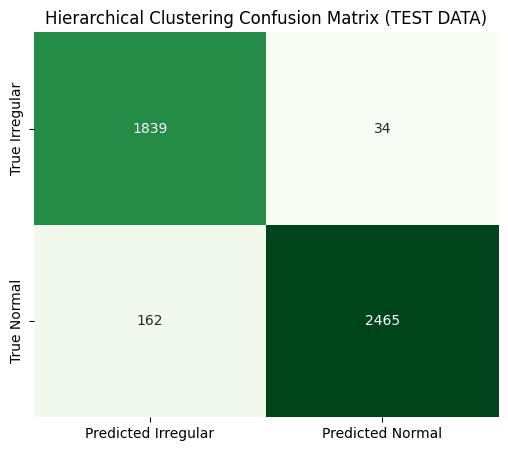

In [ ]:
# ==========================================
# 7. LOADING AND PREPARING TEST DATA
# ==========================================
test_path = "/content/drive/MyDrive/Colab Notebooks/ECG5000/ECG5000_TEST.arff"
test_data, _ = arff.loadarff(test_path)
test_df = pd.DataFrame(test_data)

# Decode test labels
for col in test_df.columns:
    if test_df[col].dtype == object:
        test_df[col] = test_df[col].str.decode('utf-8')

X_test_raw = test_df.iloc[:, :-1].values.astype(float)
y_test_ground_truth = test_df.iloc[:, -1].values

# Apply the SAME bandpass filter used in training
X_test_filt = np.array([bandpass_filter(row) for row in X_test_raw])

# Extract features using the TRAINED mean_normal template
X_test_features = get_correlation_features(X_test_filt, mean_normal)

# ==========================================
# 8. TEST DATA CLUSTERING (Using best_k from Training)
# ==========================================
# Scale the test features using the TRAINED scaler from training data
X_test_scaled = scaler_hierarchical_train.transform(X_test_features)

# Compute linkage matrix for the test data for plotting the dendrogram
linkage_matrix_test = linkage(X_test_scaled, 'ward')

# Use fcluster to get labels for the best_k found during training
test_labels_hc = fcluster(linkage_matrix_test, best_k_hc_train, criterion='maxclust')

# Map Test clusters to Binary (Identifying the Normal Cluster)
unique_test_clusters_hc = np.unique(test_labels_hc)
if len(unique_test_clusters_hc) > 0:
    test_cluster_means_hc = [np.mean(X_test_features[test_labels_hc == i, 0]) for i in unique_test_clusters_hc]
    normal_cluster_test_hc = unique_test_clusters_hc[np.argmax(test_cluster_means_hc)]
else:
    normal_cluster_test_hc = 0 # Fallback

# Convert to Binary: 1 for Normal, 0 for Irregular
y_test_pred = np.zeros(len(test_labels_hc))
y_test_pred[test_labels_hc == normal_cluster_test_hc] = 1

# Ground Truth Binary
y_test_true = (y_test_ground_truth == '1').astype(int)

# ==========================================
# 9. FINAL PERFORMANCE METRICS & VISUALIZATION
# ==========================================
print("\n--- FINAL TEST SET EVALUATION (Hierarchical Clustering) ---")
accuracy_test = accuracy_score(y_test_true, y_test_pred)
f1_test = f1_score(y_test_true, y_test_pred)
print(f"Accuracy: {accuracy_test:.4f}")
print(f"F1-Score: {f1_test:.4f}")

# Visualize Test Confusion Matrix
plt.figure(figsize=(6, 5))
test_cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=['Predicted Irregular', 'Predicted Normal'],
            yticklabels=['True Irregular', 'True Normal'])
plt.title('Hierarchical Clustering Confusion Matrix (TEST DATA)')
plt.show()

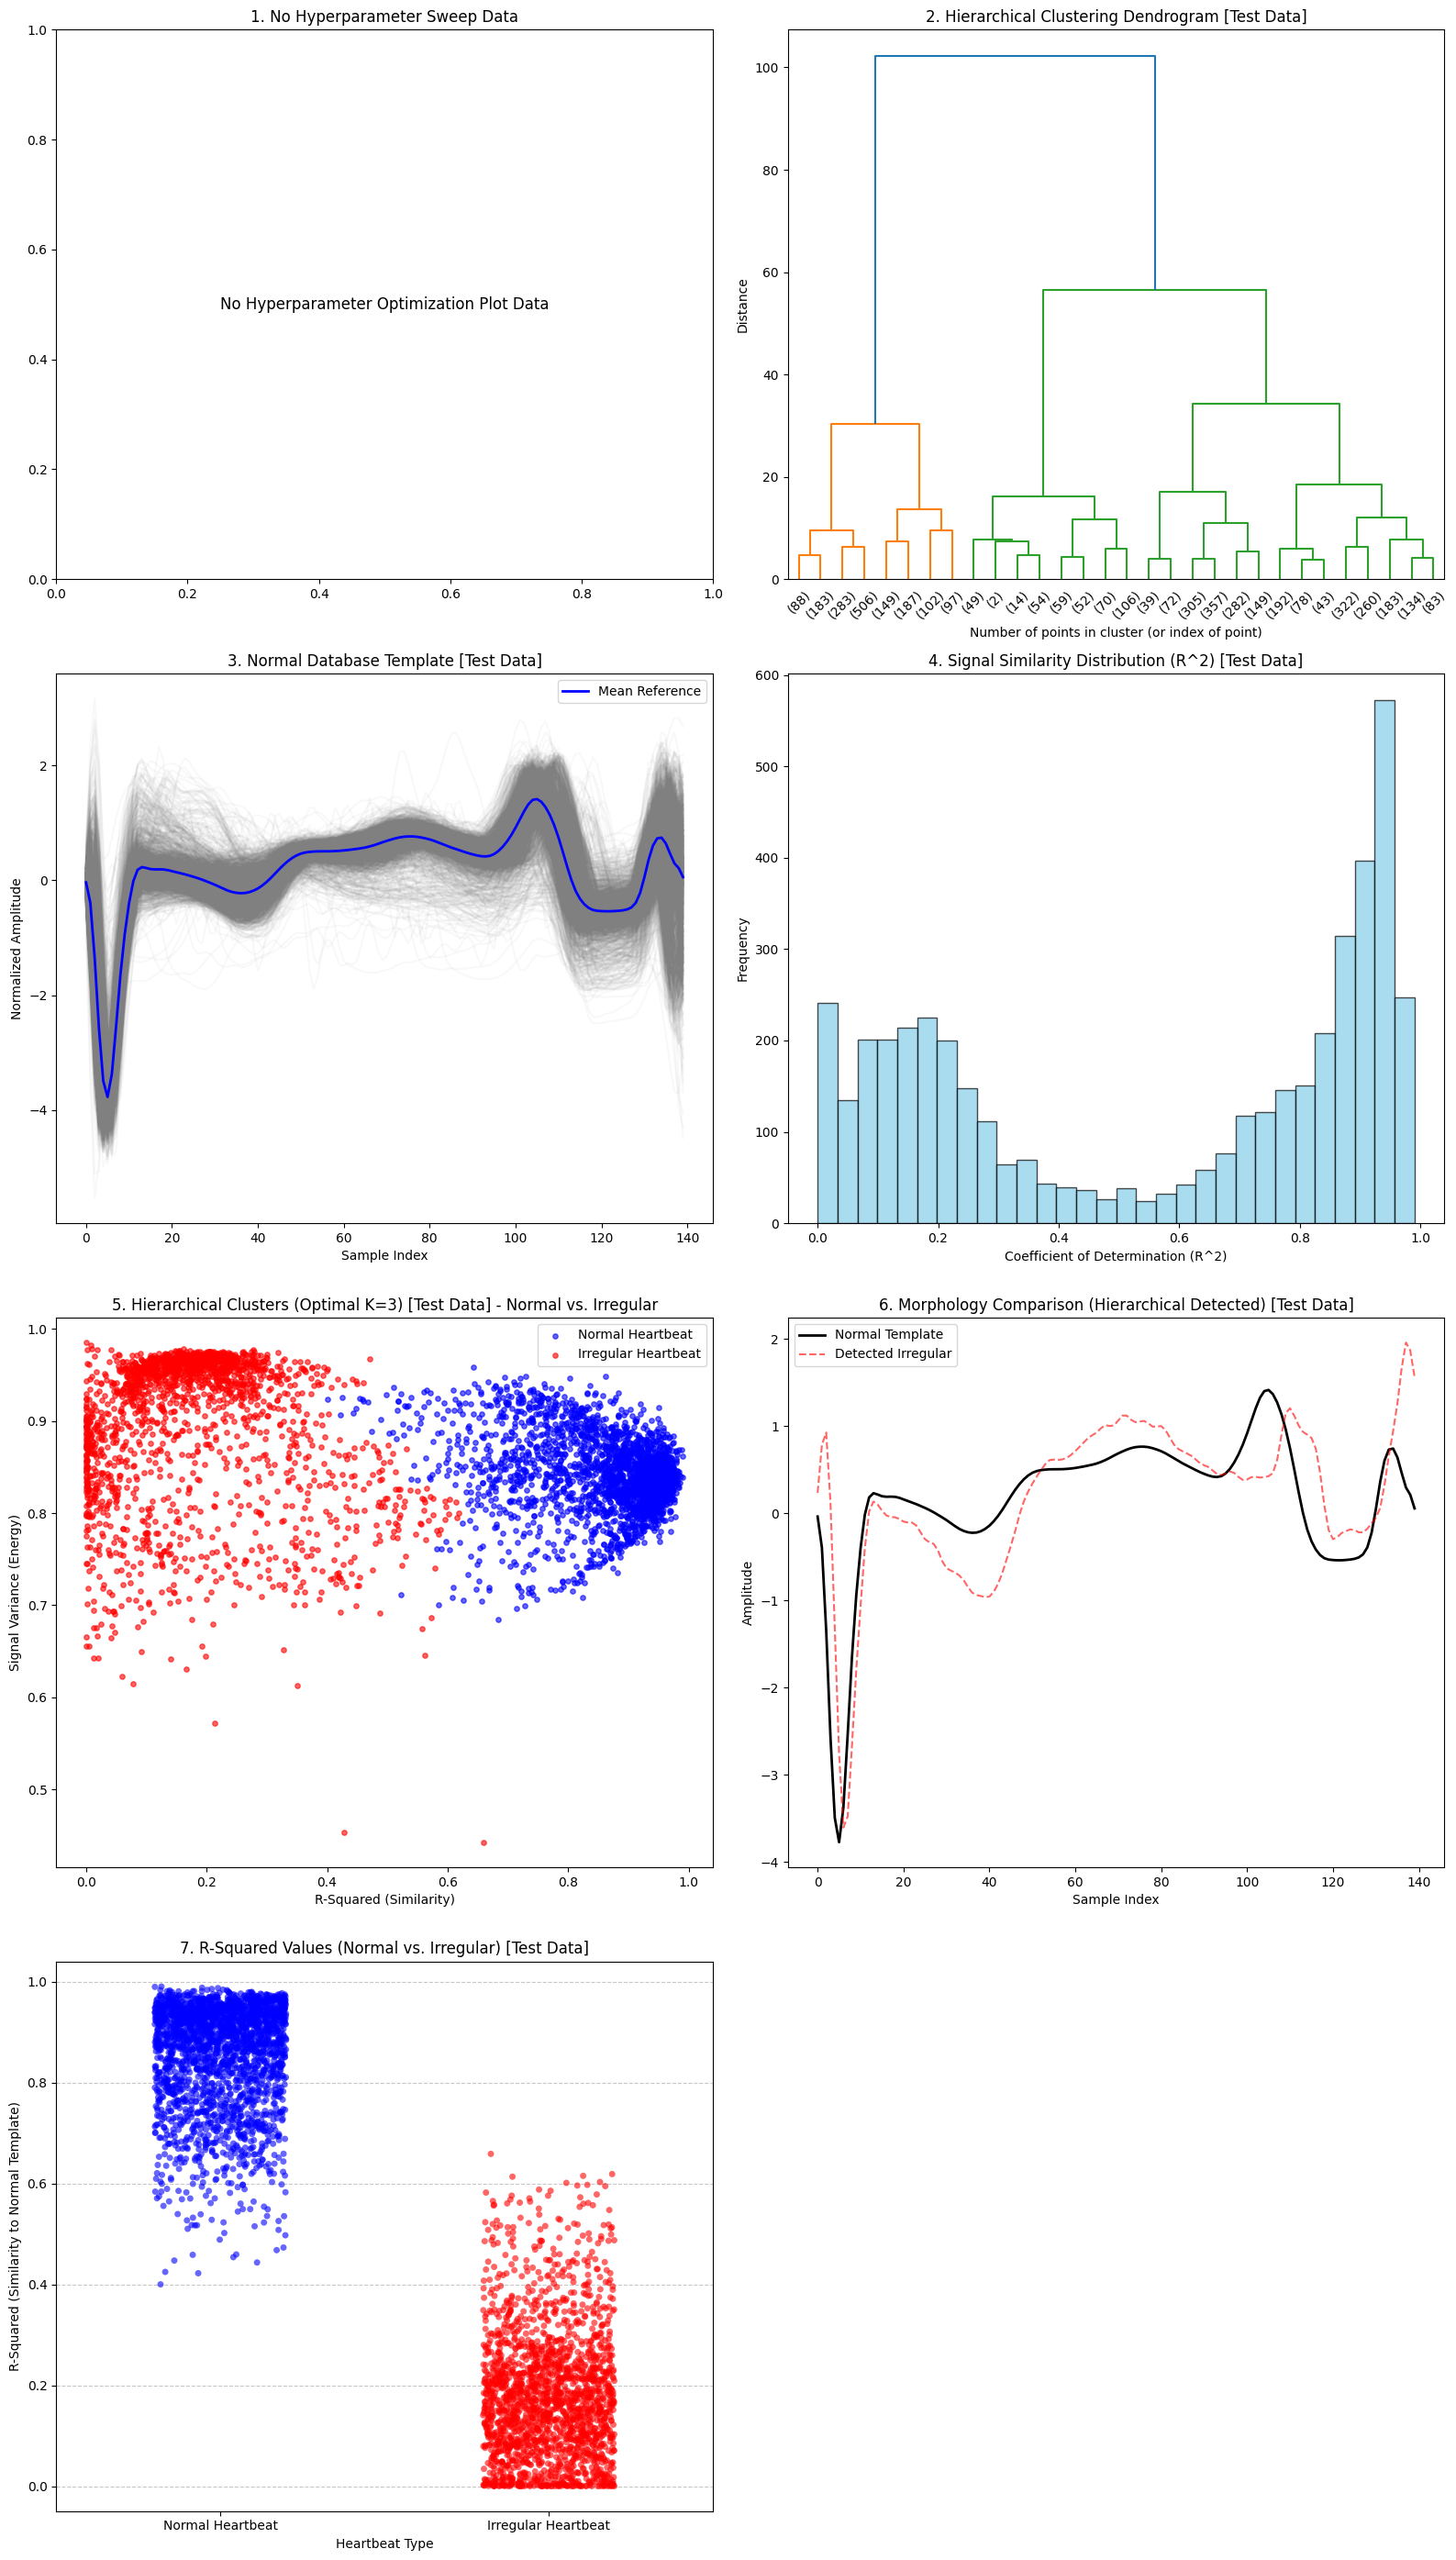

In [ ]:
X_test_normal = X_test_filt[(y_test_ground_truth == '1')]

# The linkage_matrix_test is now computed in the previous cell (Pebcs8lxdKwG)
plot_hierarchical_report(X_test_raw, X_test_filt, X_test_normal, mean_normal, test_labels_hc, X_test_features, linkage_matrix_test, valid_hp_values=None, scores=None, best_hp=best_k_hc_train, title_suffix="[Test Data]")

In [ ]:
X_test_normal = X_test_filt[(y_test_ground_truth == '1')]

### Test Data Optimization Report